In [579]:
print("Versão do Python:")
!python --version

Versão do Python:
Python 3.14.4


## Libraries


In [580]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## Importa Bibliotecas base

In [581]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Ler arquivos CSV's

In [582]:
base_cadastros = pd.read_csv("data/base_cadastral.csv", sep=";" )
base_info = pd.read_csv("data/base_info.csv", sep=";" )
base_pagamentos_desenvolvimento = pd.read_csv("data/base_pagamentos_desenvolvimento.csv", sep=";" )
base_pagamentos_teste = pd.read_csv("data/base_pagamentos_teste.csv", sep=";" )

display(base_cadastros.head())
display(base_info.head())
display(base_pagamentos_desenvolvimento.head())
display(base_pagamentos_teste.head())

,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


In [583]:
base_pagamentos_desenvolvimento["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_EMISSAO_DOCUMENTO"], errors="coerce")
base_pagamentos_desenvolvimento["DATA_PAGAMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_PAGAMENTO"], errors="coerce")
base_pagamentos_desenvolvimento["DATA_VENCIMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_VENCIMENTO"], errors="coerce")

base_pagamentos_teste["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(base_pagamentos_teste["DATA_EMISSAO_DOCUMENTO"], errors="coerce")
base_pagamentos_teste["DATA_VENCIMENTO"] = pd.to_datetime(base_pagamentos_teste["DATA_VENCIMENTO"], errors="coerce")


## Criar Varivel de Inadimplencia

In [584]:
base_pagamentos_desenvolvimento["INADIMPLENTE"] = (base_pagamentos_desenvolvimento["DATA_PAGAMENTO"] >= base_pagamentos_desenvolvimento["DATA_VENCIMENTO"]+pd.Timedelta(days=5)).astype(int)
base_pagamentos_desenvolvimento["INADIMPLENTE"].value_counts()

INADIMPLENTE
0    71978
1     5436
Name: count, dtype: int64

## Marge Base

<class 'pandas.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_CLIENTE              77414 non-null  int64         
 1   SAFRA_REF               77414 non-null  str           
 2   RENDA_MES_ANTERIOR      71282 non-null  float64       
 3   NO_FUNCIONARIOS         69827 non-null  float64       
 4   DATA_EMISSAO_DOCUMENTO  77414 non-null  datetime64[us]
 5   DATA_PAGAMENTO          77414 non-null  datetime64[us]
 6   DATA_VENCIMENTO         77414 non-null  datetime64[us]
 7   VALOR_A_PAGAR           76244 non-null  float64       
 8   TAXA                    77414 non-null  float64       
 9   INADIMPLENTE            77414 non-null  int64         
 10  DATA_CADASTRO           77414 non-null  str           
 11  DDD                     70000 non-null  str           
 12  FLAG_PF                 219 non-null    str           
 1

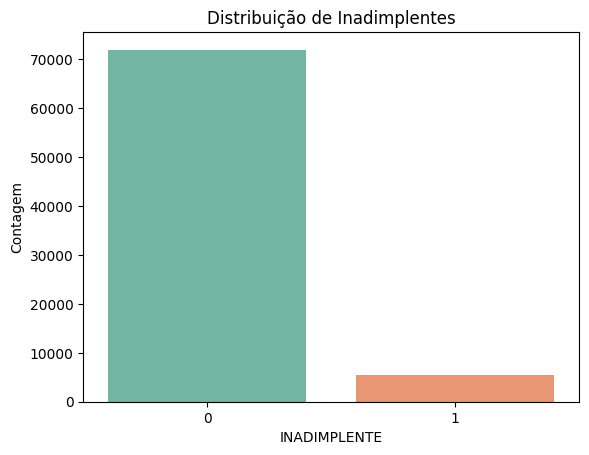

In [585]:
base_mensal=pd.merge(base_info, base_pagamentos_desenvolvimento,  on=["ID_CLIENTE", "SAFRA_REF"], how="right")
base_model = pd.merge(base_mensal, base_cadastros, on=["ID_CLIENTE"], how="inner")
base_model["MISSING"] = np.zeros(len(base_model), dtype=int)
sns.barplot(x=base_model["INADIMPLENTE"].value_counts().index, y=base_model["INADIMPLENTE"].value_counts().values,  hue=base_model["INADIMPLENTE"].value_counts().index,palette="Set2",
    legend=False)
plt.title("Distribuição de Inadimplentes")
plt.ylabel("Contagem")
base_model.info()

In [586]:
base_mensal=pd.merge(base_info, base_pagamentos_teste,  on=["ID_CLIENTE", "SAFRA_REF"], how="right")
base_submit = pd.merge(base_mensal, base_cadastros, on=["ID_CLIENTE"], how="left")
base_submit["MISSING"] = np.zeros(len(base_submit), dtype=int)
base_submit.info()

<class 'pandas.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_CLIENTE              12275 non-null  int64         
 1   SAFRA_REF               12275 non-null  str           
 2   RENDA_MES_ANTERIOR      11549 non-null  float64       
 3   NO_FUNCIONARIOS         11108 non-null  float64       
 4   DATA_EMISSAO_DOCUMENTO  12275 non-null  datetime64[us]
 5   DATA_VENCIMENTO         12275 non-null  datetime64[us]
 6   VALOR_A_PAGAR           12144 non-null  float64       
 7   TAXA                    12275 non-null  float64       
 8   DATA_CADASTRO           12237 non-null  str           
 9   DDD                     10898 non-null  str           
 10  FLAG_PF                 47 non-null     str           
 11  SEGMENTO_INDUSTRIAL     12021 non-null  str           
 12  DOMINIO_EMAIL           12067 non-null  str           
 1

## Analise EDA

In [587]:
variaveis_numericas = ["RENDA_MES_ANTERIOR", "VALOR_A_PAGAR", "NO_FUNCIONARIOS", "TAXA"]
vars_cat= ["SAFRA_REF", "DDD", "FLAG_PF", "SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "PORTE", "CEP_2_DIG"]
target = "INADIMPLENTE"

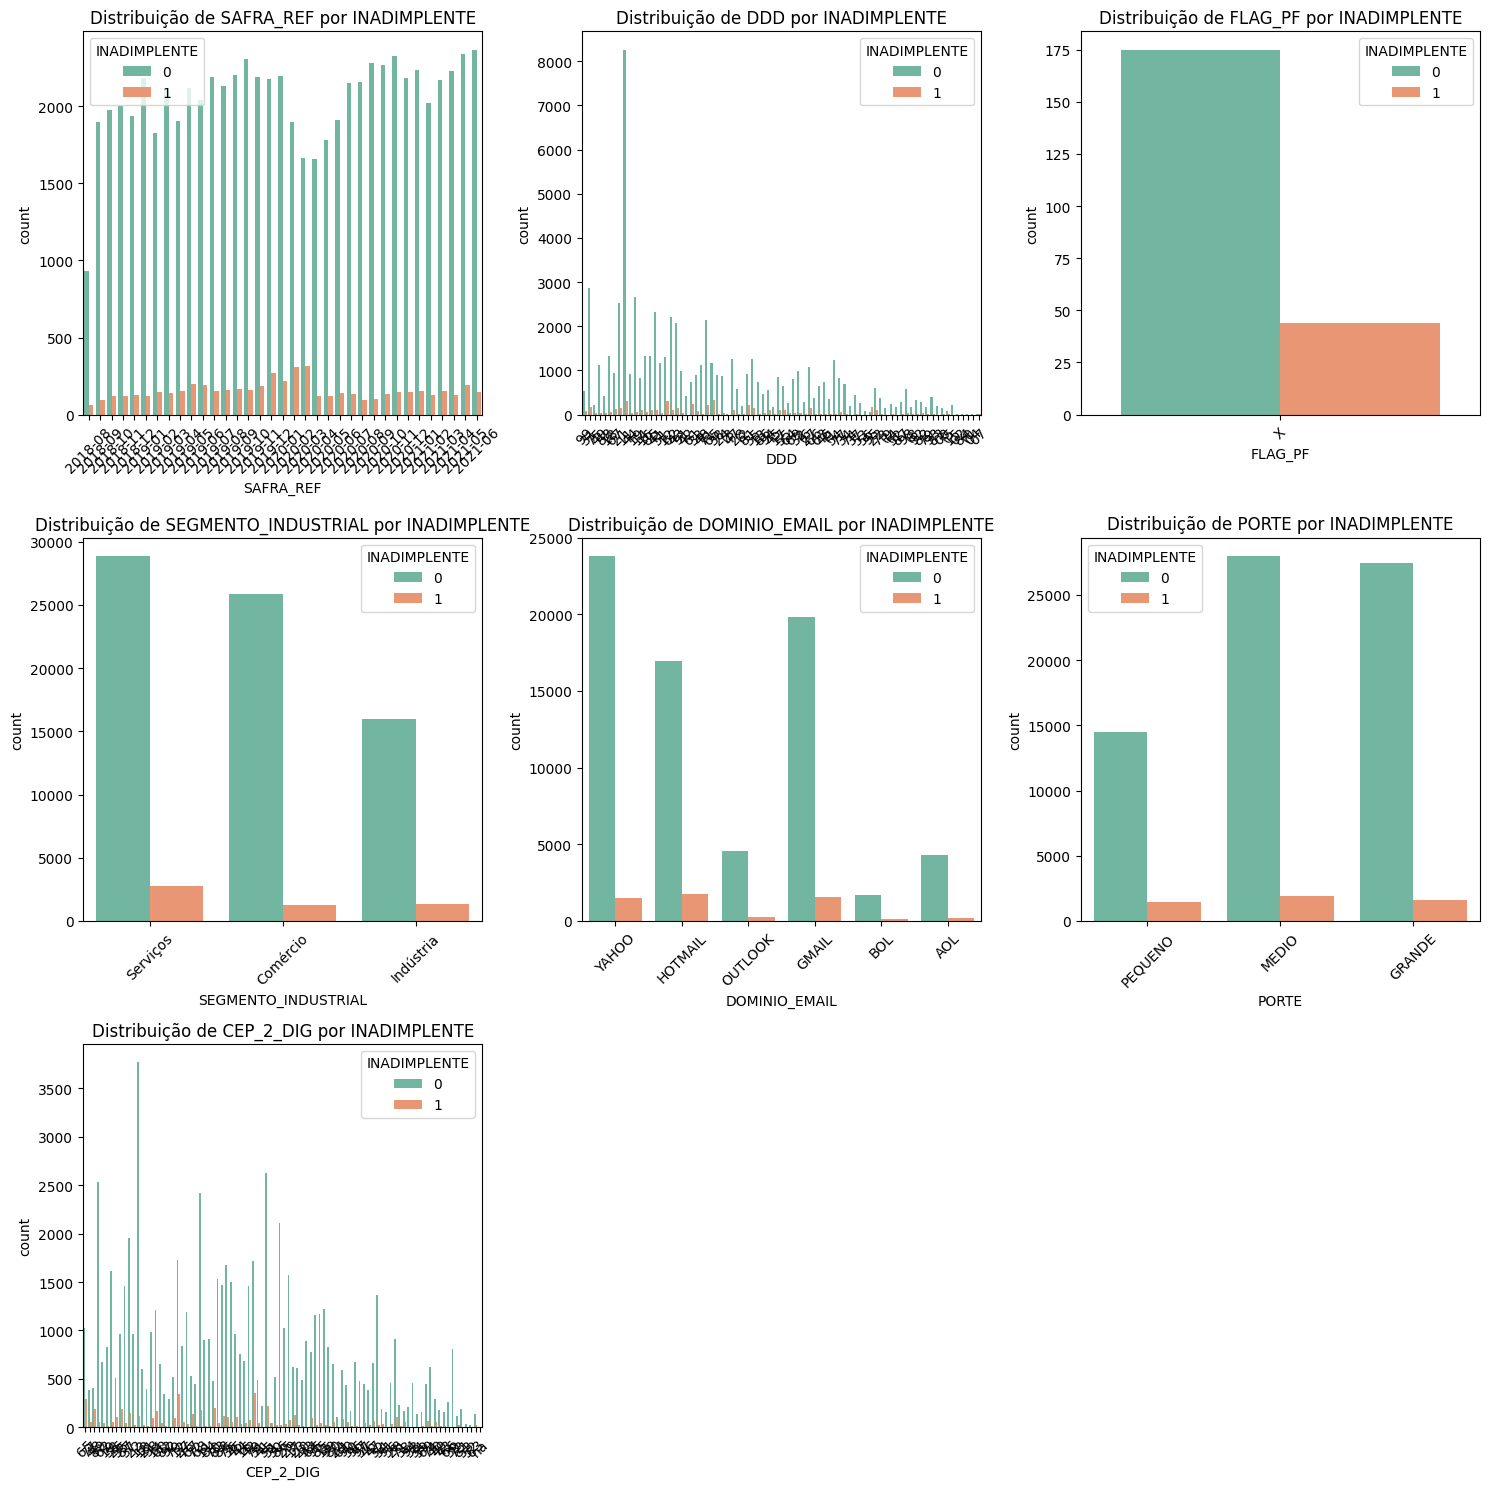

In [588]:
import math

num_vars = len(vars_cat)
n_cols = 3
n_rows = math.ceil(num_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# achatar o array de axes para facilitar o loop
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    sns.countplot(
        data=base_model, 
        x=col, 
        hue=target, 
        palette="Set2", 
        ax=axes[i]
    )
    axes[i].set_title(f"Distribuição de {col} por {target}")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

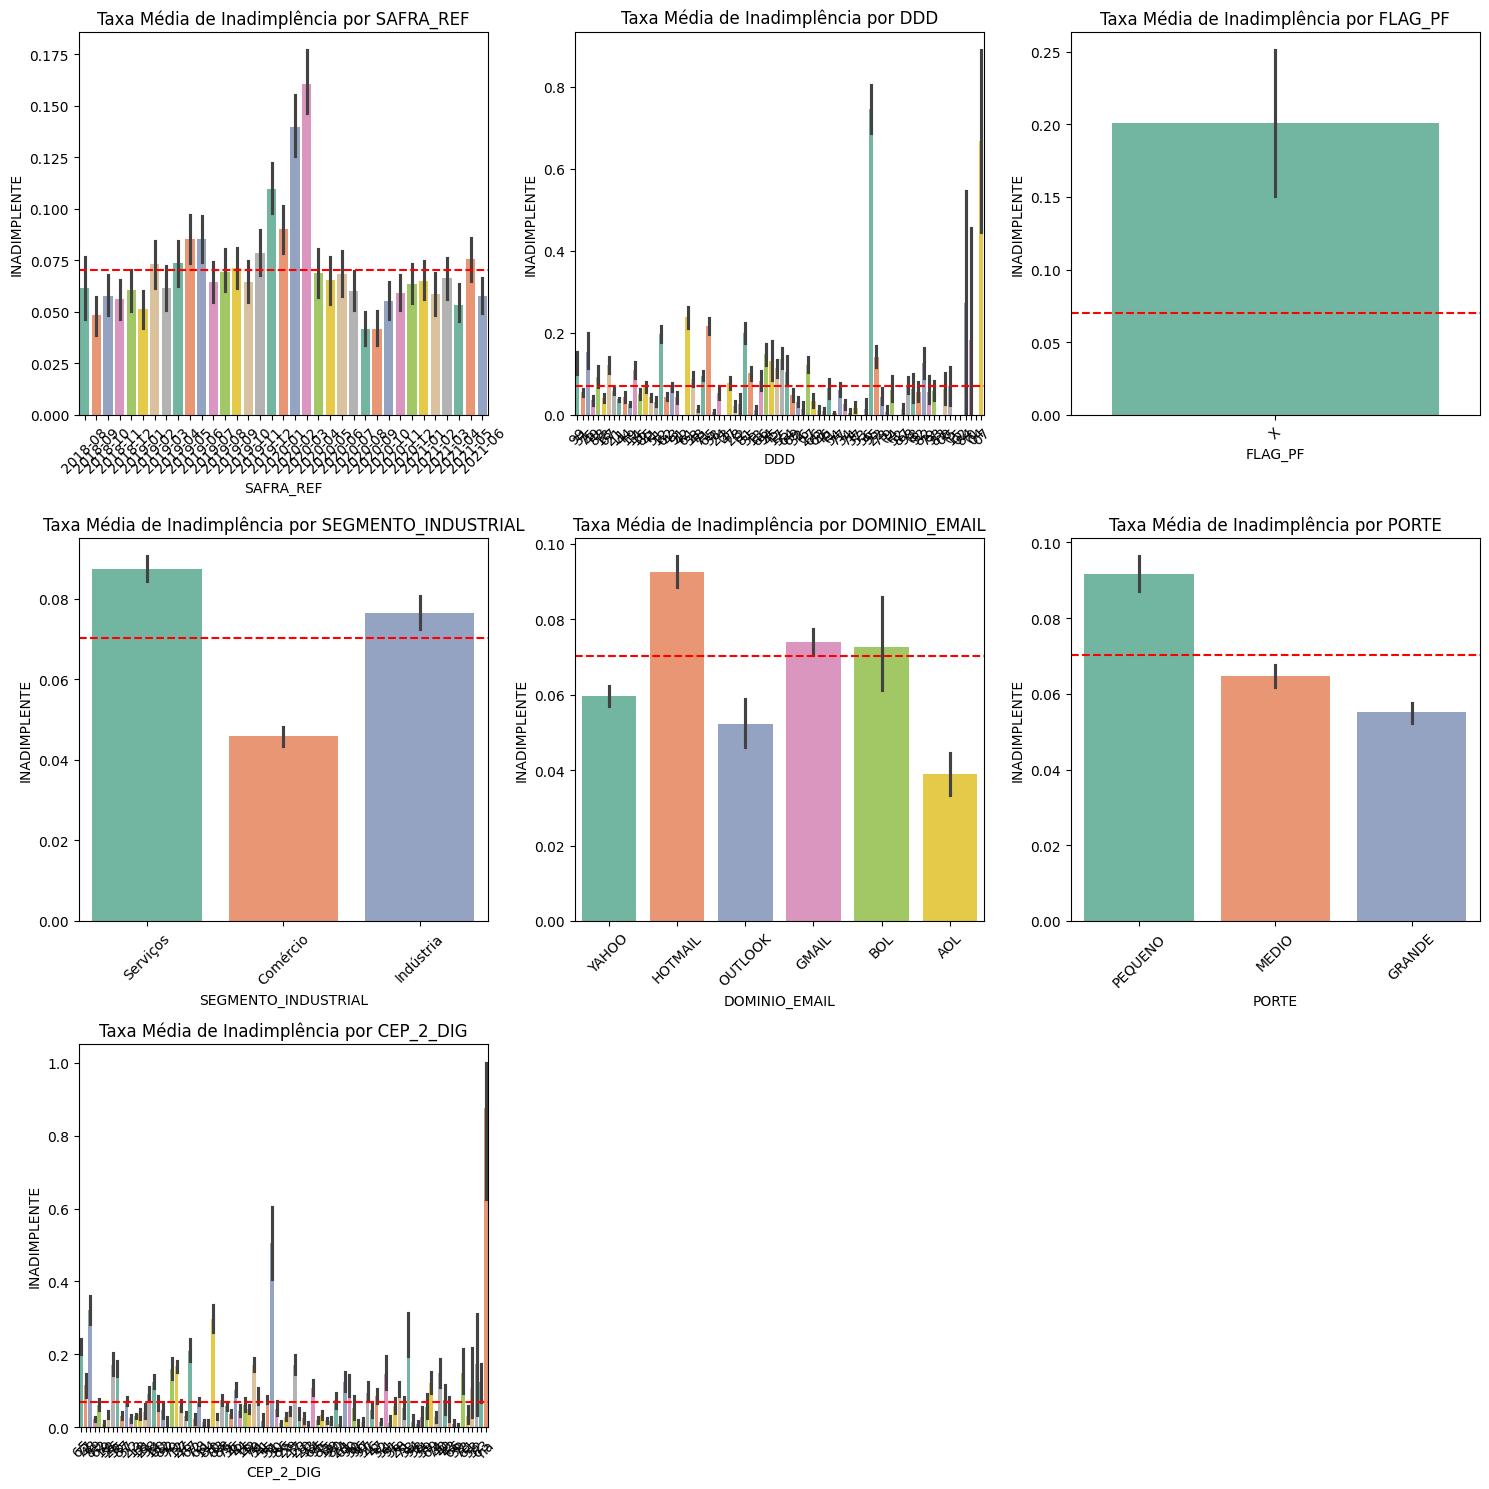

In [ ]:
import math

num_vars = len(vars_cat)
n_cols = 3
n_rows = math.ceil(num_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

if num_vars == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(vars_cat):
    sns.barplot(data=base_model, x=col,y=target,palette="Set2", ax=axes[i], hue=col, legend=False)
    
    axes[i].set_title(f"Taxa Média de Inadimplência por {col}")
    axes[i].axhline( base_model[target].mean(),color='red', linestyle='--', label='Média Global')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

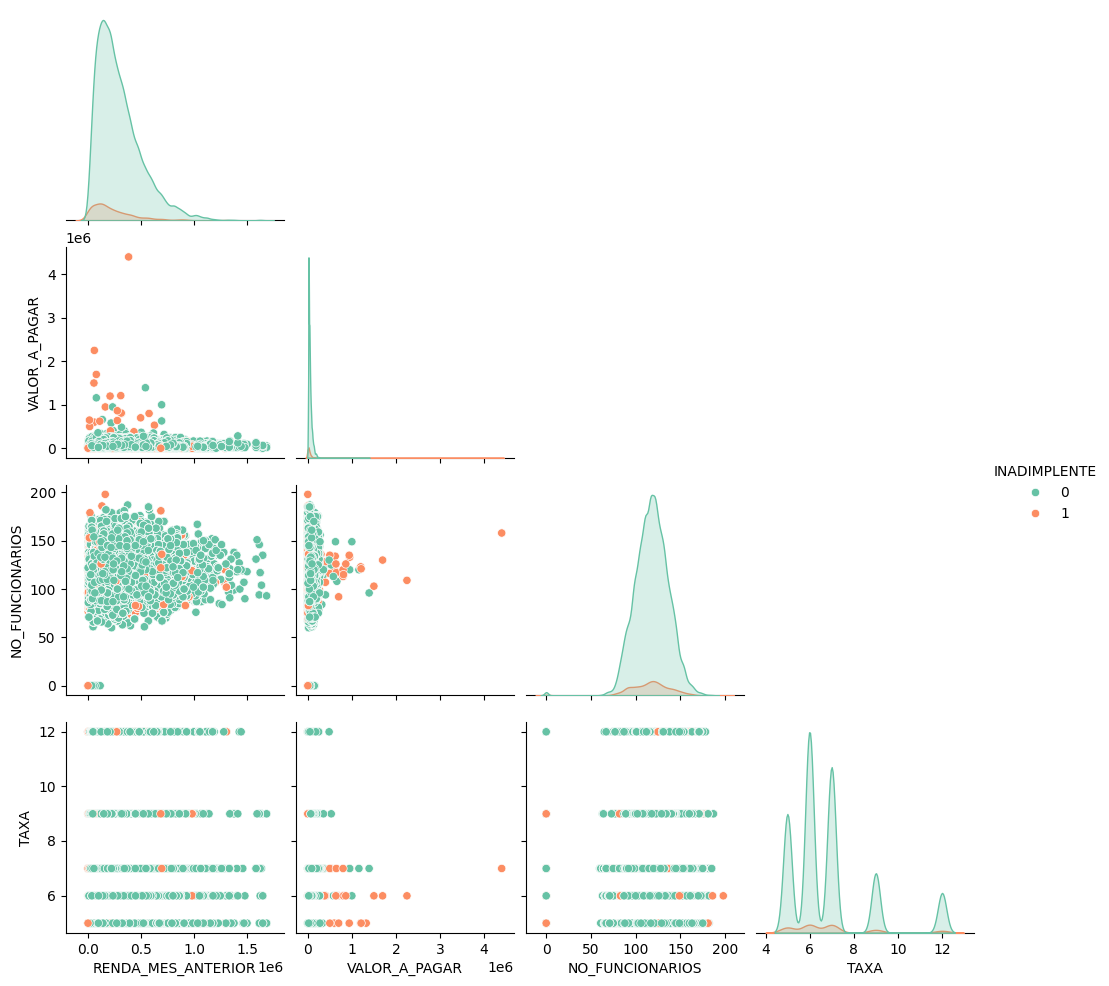

In [ ]:
sns.pairplot(base_model[variaveis_numericas], diag_kind="kde", corner=True, hue="INADIMPLENTE", palette="Set2")

### Split base MODEL para TREINO e TESTE

In [ ]:
safras_ordenadas = sorted(base_model["SAFRA_REF"].unique())

n_test_safras = 5

safras_train = safras_ordenadas[:-n_test_safras]
safras_test  = safras_ordenadas[-n_test_safras:]

train = base_model[base_model["SAFRA_REF"].isin(safras_train)]
test  = base_model[base_model["SAFRA_REF"].isin(safras_test)]

print(f"Safras treino: {safras_train[0]} -> {safras_train[-1]}")
print(f"Safras teste:  {safras_test[0]} -> {safras_test[-1]}")
print(f"Treino: {len(train):,} linhas | Teste: {len(test):,} linhas")
print(f"Proporção Teste/Treino: {len(test)/len(train):.2%}")


Safras treino: 2018-08 -> 2021-01
Safras teste:  2021-02 -> 2021-06
Treino: 65,540 linhas | Teste: 11,874 linhas
Proporção Teste/Treino: 18.12%


## Imputações na base de TRAIN, Teste e Submit

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

In [ ]:
class ImputacaoFLAG_PF(BaseEstimator, TransformerMixin):
    def __init__(self, col="FLAG_PF", PJ=0, PF=1):
        self.col = col
        self.PF_PJ = {"X":PF, np.nan:PJ}

    def fit(self, X,y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        X[self.col] = X[self.col].map(self.PF_PJ)
        
        return X


In [ ]:
class ImputacaoValueUnknown(BaseEstimator, TransformerMixin):
    def __init__(self, col="DOMINIO_EMAIL", fill_value="UNKNOWN"):
        self.col = col
        self.fill_value = fill_value

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        
        X[self.col] = X[self.col].fillna(self.fill_value)
        
        return X

In [ ]:
class ImputacaoHierarquicaValor(BaseEstimator, TransformerMixin):
    def __init__(self, col="VALOR_A_PAGAR"):
        self.col = col
        
    def fit(self, X, y=None):
        self.med_cs_ = X.groupby(["ID_CLIENTE", "SAFRA_REF"])[self.col].median().reset_index()
        self.med_cs_.columns = ["ID_CLIENTE", "SAFRA_REF", "med_cs"]
        
        self.med_c_ = X.groupby("ID_CLIENTE")[self.col].median().reset_index()
        self.med_c_.columns = ["ID_CLIENTE", "med_c"]
        
        self.med_global_ = X[self.col].median()
        
        return self

    def transform(self, X):
        X = X.copy()
        
        # flag de missing
        X["MISSING"] += X[self.col].isna().astype(int)
        
        X = X.merge(self.med_cs_, on=["ID_CLIENTE", "SAFRA_REF"], how="left")
        X = X.merge(self.med_c_, on="ID_CLIENTE", how="left")
        
        # Imputação Hierárquica
        X[self.col] = X[self.col].fillna(X["med_cs"])
        X[self.col] = X[self.col].fillna(X["med_c"])
        X[self.col] = X[self.col].fillna(self.med_global_)
        
        X = X.drop(columns=["med_cs", "med_c"])
        
        return X

In [ ]:
class ImputacaoCEP2(BaseEstimator, TransformerMixin):
    def __init__(self, col="CEP_2_DIG"):
        self.col = col

    def fit(self, X, y=None):
        cep_temp = X[self.col].replace('na', np.nan).astype("Int16")
        self.moda_ = cep_temp.mode()[0]
        return self

    def transform(self, X):
        X = X.copy()
        X[self.col] = X[self.col].replace('na', np.nan).astype("Int16")
        X[self.col] = X[self.col].fillna(self.moda_)
        return X

In [ ]:
class ImputacaoDDDGeografico(BaseEstimator, TransformerMixin):
    def __init__(self, col_ddd="DDD", col_cep="CEP_2_DIG"):
        self.col_ddd = col_ddd
        self.col_cep = col_cep
        
        self.ddd_para_cep2_ranges = {
            11: [(1, 11)], 12: [(12, 12)], 13: [(13, 13)], 14: [(14, 14)], 15: [(15, 15)],
            16: [(16, 16)], 17: [(17, 17)], 18: [(18, 18)], 19: [(19, 19)], 21: [(20, 26)],
            22: [(27, 28)], 27: [(29, 29)], 31: [(30, 33), (35, 35)], 32: [(36, 36)],
            33: [(39, 39)], 34: [(34, 34)], 37: [(37, 37)], 38: [(38, 38)], 71: [(40, 41)],
            73: [(47, 47)], 74: [(43, 44)], 75: [(42, 42)], 77: [(45, 46)], 79: [(48, 49)],
            81: [(50, 50), (52, 55)], 87: [(51, 51), (56, 56)], 82: [(57, 57)], 83: [(58, 58)],
            84: [(59, 59)], 85: [(60, 61)], 88: [(62, 63)], 86: [(64, 64)], 98: [(65, 65)],
            99: [(66, 66)], 91: [(67, 67)], 93: [(68, 68)], 96: [(69, 69)], 61: [(70, 73)],
            62: [(74, 74), (76, 76)], 64: [(75, 75)], 63: [(77, 77)], 65: [(78, 78)],
            67: [(79, 79)], 41: [(80, 83)], 42: [(84, 84)], 43: [(86, 86)], 44: [(85, 85), (87, 87)],
            48: [(88, 88)], 47: [(89, 89)], 51: [(90, 92), (94, 94)], 53: [(96, 96)],
            54: [(93, 93), (95, 95), (99, 99)], 55: [(97, 97), (98, 98)],
        }
        
        # Gerar o mapeamento inverso (CEP -> DDD)
        self.cep2_para_ddd = {
            cep: ddd
            for ddd, ranges in self.ddd_para_cep2_ranges.items()
            for start, end in ranges
            for cep in range(start, end + 1)
        }

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        
        # Limpeza da coluna DDD
        X[self.col_ddd] = (
            X[self.col_ddd]
            .astype(str)
            .str.replace(r"\D", "", regex=True)
            .replace("", np.nan)
        )
        X[self.col_ddd] = pd.to_numeric(X[self.col_ddd], errors='coerce').astype("Int16")
        
        # Invalidar DDDs fora da regra de negócio
        valid_ddds = self.ddd_para_cep2_ranges.keys()
        X.loc[~X[self.col_ddd].isin(valid_ddds), self.col_ddd] = pd.NA
        
        # Imputação Geográfica (onde DDD é nulo)
        mask_nulo = X[self.col_ddd].isna()
        X.loc[mask_nulo, self.col_ddd] = (
            X.loc[mask_nulo, self.col_cep]
            .map(self.cep2_para_ddd)
            .astype("Int16")
        )
        
        return X

In [ ]:
pipeline = Pipeline(steps=[
    ("imputa_PF_PJ", ImputacaoFLAG_PF(col="FLAG_PF", PJ=0, PF=1)),

    ("imputa_email", ImputacaoValueUnknown(col="DOMINIO_EMAIL")),
    ("imputa_segmento_industrial",    ImputacaoValueUnknown(col="SEGMENTO_INDUSTRIAL")),
    ("imputa_porte", ImputacaoValueUnknown(col="PORTE")),

    ("imputa_valor_a_pagar", ImputacaoHierarquicaValor(col="VALOR_A_PAGAR")),
    ("imputa_valor_mes_anterior", ImputacaoHierarquicaValor(col="RENDA_MES_ANTERIOR")),
    ("imputa_no_funcionarios", ImputacaoHierarquicaValor(col="NO_FUNCIONARIOS")),

    ("imputa_cep_2_dig", ImputacaoCEP2(col="CEP_2_DIG")),

    ("imputa_ddd_geografico", ImputacaoDDDGeografico(col_ddd="DDD", col_cep="CEP_2_DIG")),
])

# Fit só no treino
pipeline.fit(train)

# Transform em ambos
train = pipeline.transform(train)
test = pipeline.transform(test)
submission = pipeline.transform(base_submit)



## Feature Enginner

In [ ]:
# Feat

## Analise Exploratoria Pos Imputação

In [593]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 65540 entries, 0 to 65539
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_CLIENTE              65540 non-null  int64         
 1   SAFRA_REF               65540 non-null  str           
 2   RENDA_MES_ANTERIOR      65540 non-null  float64       
 3   NO_FUNCIONARIOS         65540 non-null  float64       
 4   DATA_EMISSAO_DOCUMENTO  65540 non-null  datetime64[us]
 5   DATA_PAGAMENTO          65540 non-null  datetime64[us]
 6   DATA_VENCIMENTO         65540 non-null  datetime64[us]
 7   VALOR_A_PAGAR           65540 non-null  float64       
 8   TAXA                    65540 non-null  float64       
 9   INADIMPLENTE            65540 non-null  int64         
 10  DATA_CADASTRO           65540 non-null  str           
 11  DDD                     65540 non-null  Int16         
 12  FLAG_PF                 65540 non-null  int64         
 1

In [602]:
variaveis_numericas = ["RENDA_MES_ANTERIOR", "VALOR_A_PAGAR", "NO_FUNCIONARIOS", "TAXA", "INADIMPLENTE", "MISSING"]
vars_cat= ["SAFRA_REF", "DDD", "FLAG_PF", "SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "PORTE", "CEP_2_DIG"]
target = "INADIMPLENTE"

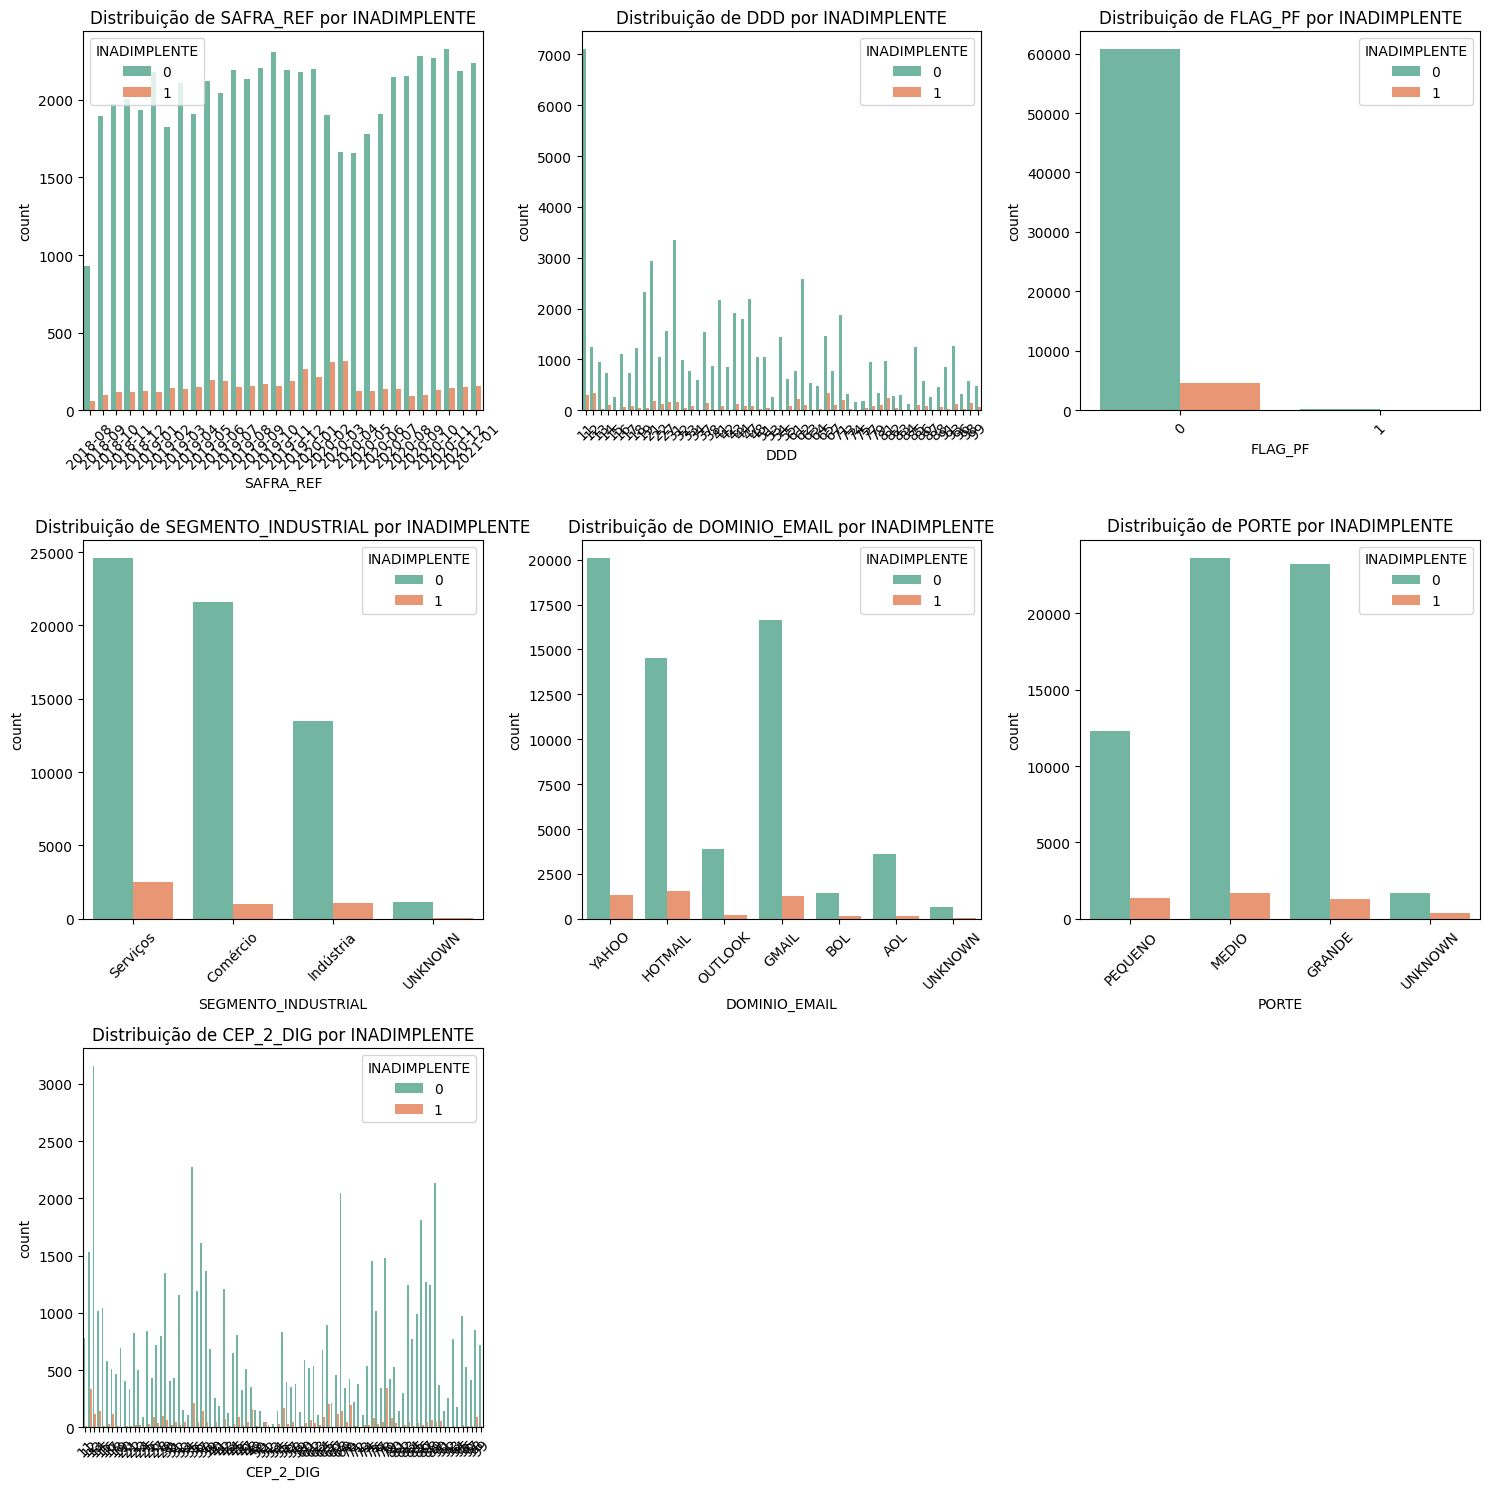

In [596]:
import math

num_vars = len(vars_cat)
n_cols = 3
n_rows = math.ceil(num_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# achatar o array de axes para facilitar o loop
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    sns.countplot(data=train, x=col, hue=target, palette="Set2", ax=axes[i])
    axes[i].set_title(f"Distribuição de {col} por {target}")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

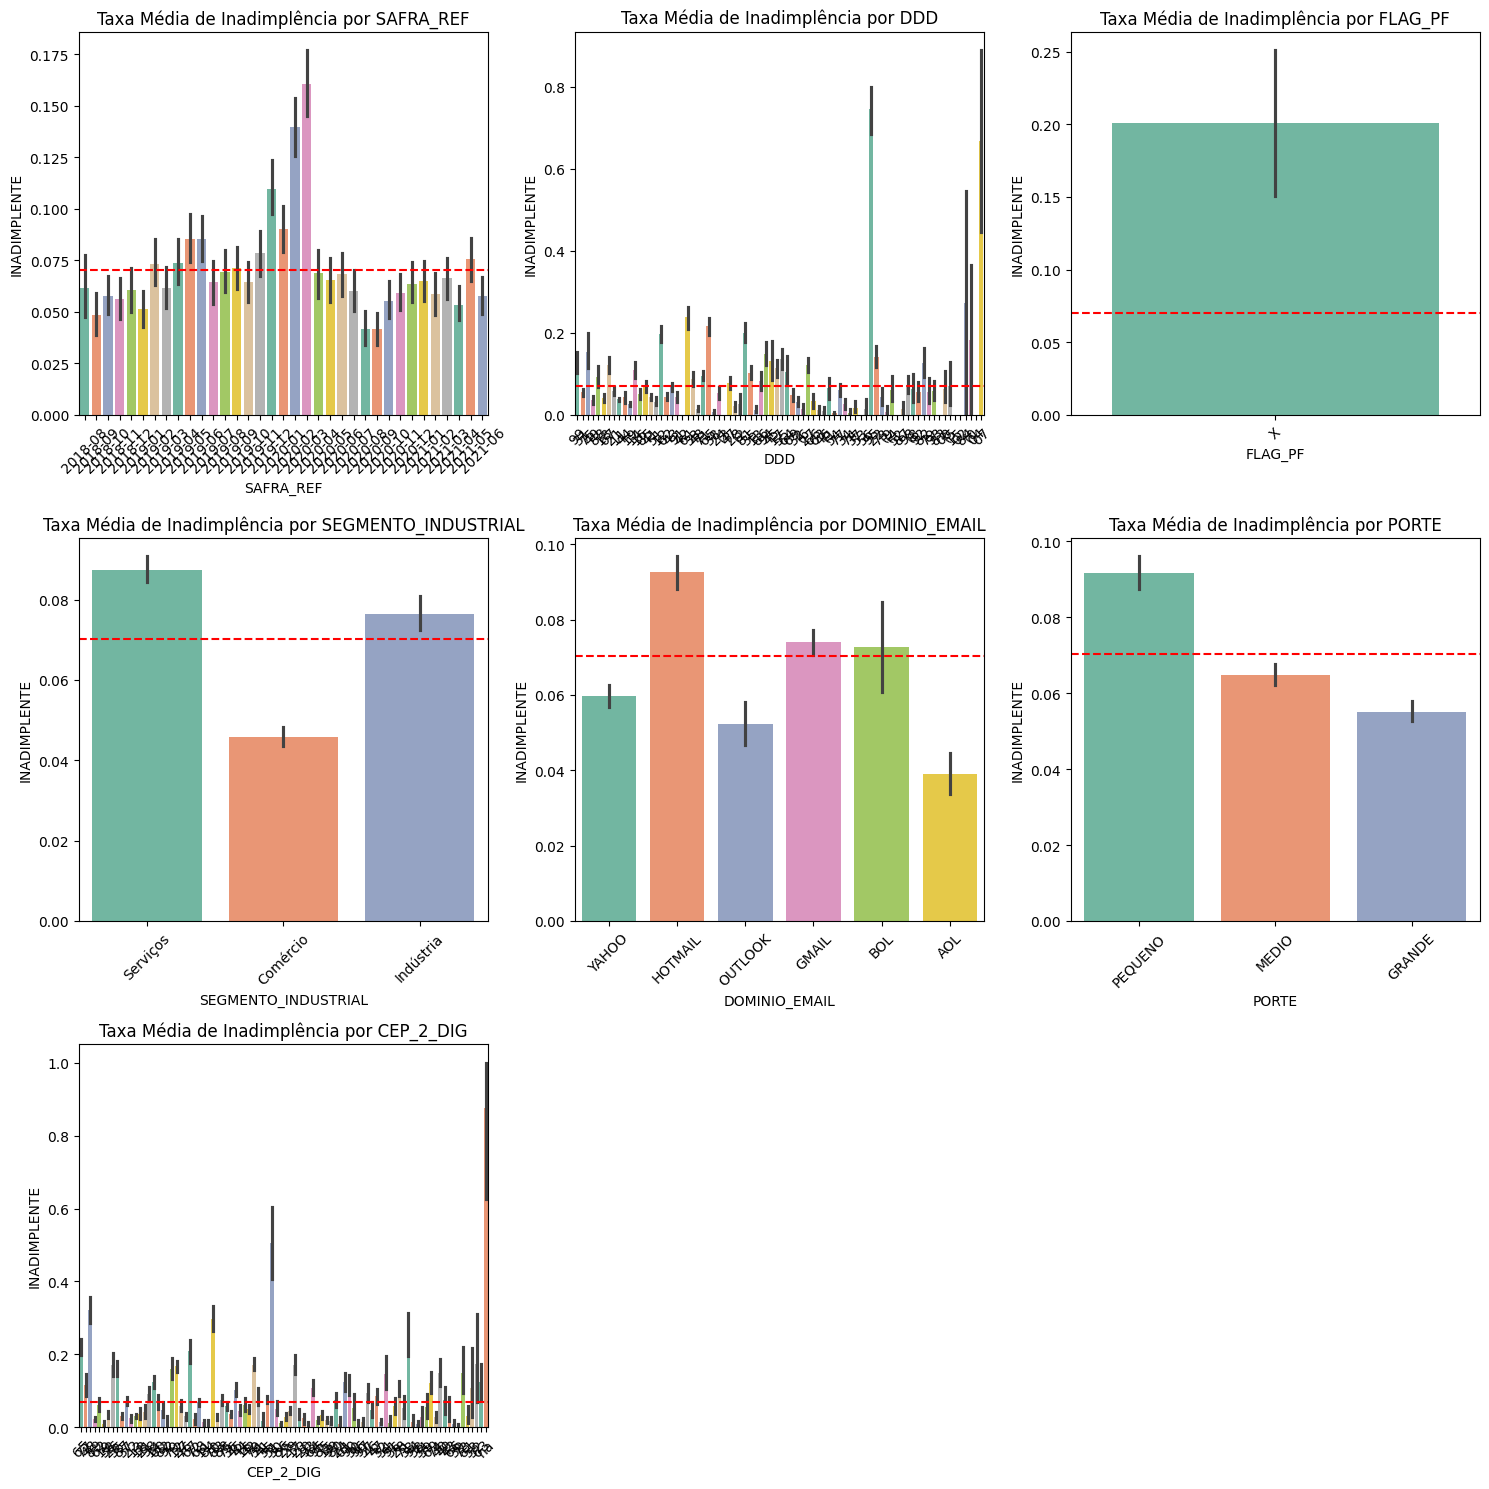

In [597]:
import math

num_vars = len(vars_cat)
n_cols = 3
n_rows = math.ceil(num_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

if num_vars == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(vars_cat):
    sns.barplot(data=base_model, x=col,y=target,palette="Set2", ax=axes[i], hue=col, legend=False)
    
    axes[i].set_title(f"Taxa Média de Inadimplência por {col}")
    axes[i].axhline( base_model[target].mean(),color='red', linestyle='--', label='Média Global')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

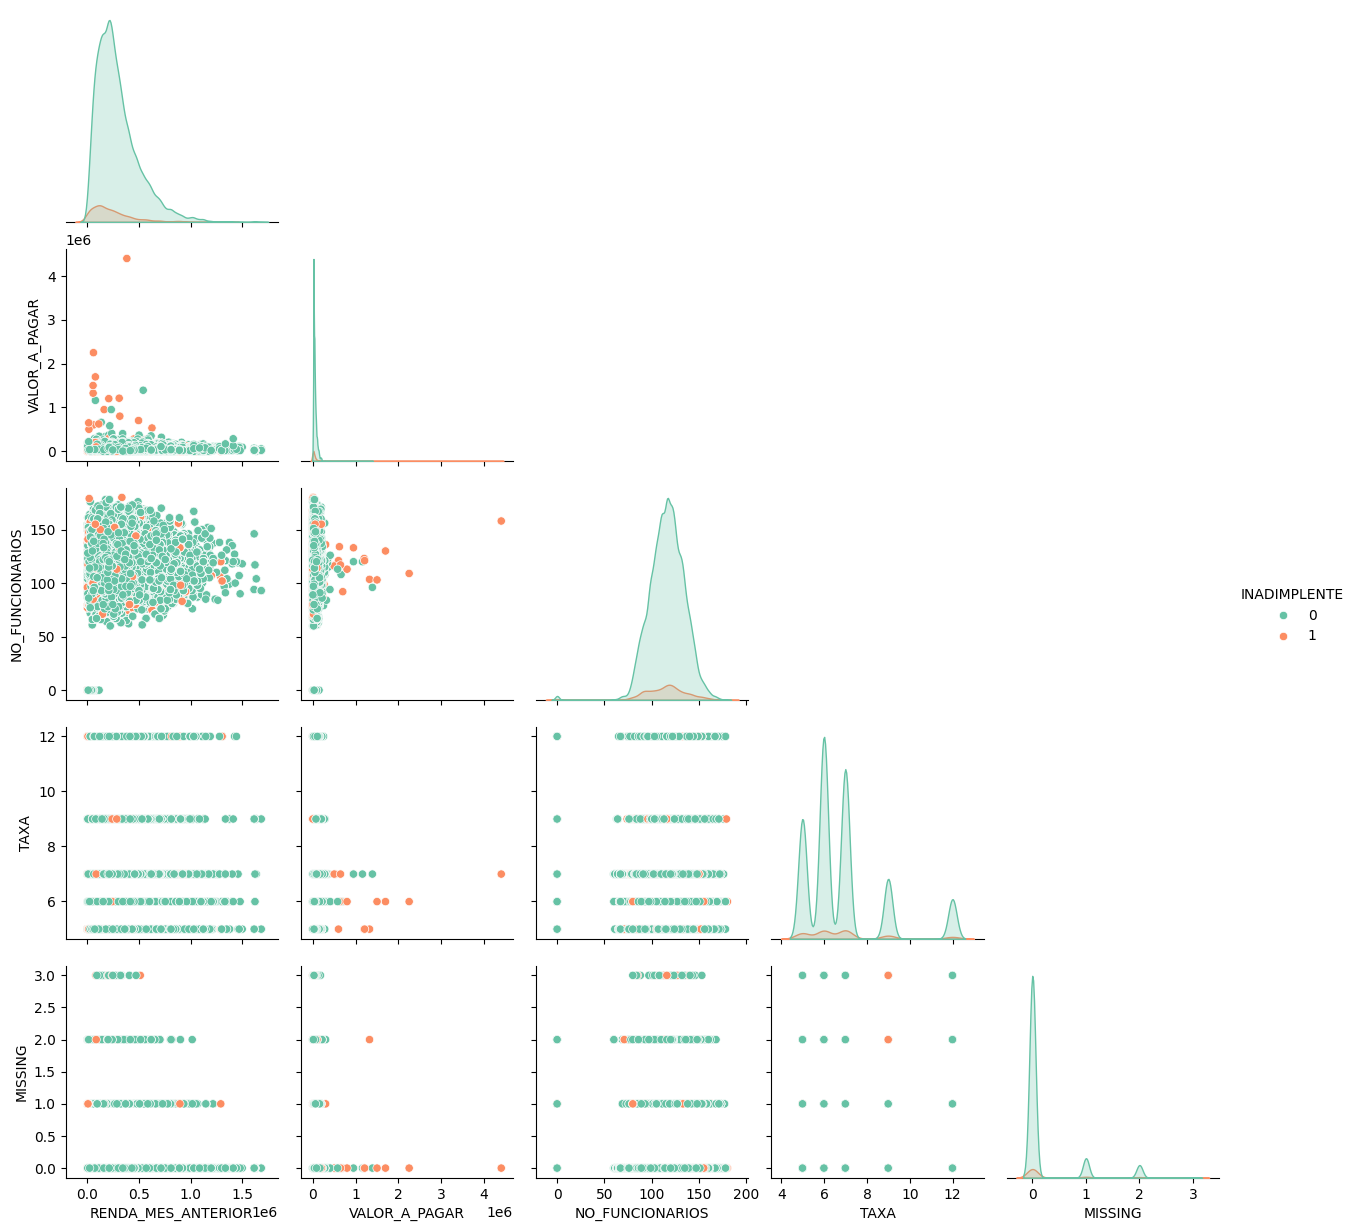

In [603]:
sns.pairplot(train[variaveis_numericas], diag_kind="kde", corner=True, hue=target, palette="Set2")